In [1]:
from typing import *

# Математика
import numpy as np
import pandas as pd
from scipy.integrate import quad
from scipy.constants import electron_mass, \
                            pi, k, \
                            elementary_charge

# Построение графиков
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Стиль графиков
# import scienceplots
# plt.style.use(['science', 'russian-font', 'grid'])

#### Сечение возбуждения $i$-го резонансного состояния электронным ударом:
$$
    \sigma_{0i}(v) = 0.28 \times 10^{-20} \text{м}^{2} \cdot 2\pi \left( \frac{27.2\ \text{эВ}}{\Delta E_{0i}} \right) f_{0i} \frac{\ln{\left( 1 + 0.5 \sqrt{(E(v) / \Delta E_{0i}) - 1} \right)}}{(E(v) / \Delta E_{0i}) + 3},
$$
где $E(v) = \frac{1}{e} \frac{m v^2}{2}$ - кинетическая энергия электрона (в эВ).

In [2]:
def sigma_0i(v: float, dE_0i: float, f_0i: float) -> float:
    ''' Сечение возбуждения i-го резонансного состояния атома '''
    E = (electron_mass * v**2 / 2) / elementary_charge
    return 0.28 * 1e-20 * 2 * pi * (27.2 / dE_0i) * f_0i * np.log(1 + 0.5 * np.sqrt(E / dE_0i - 1)) / (E / dE_0i + 3)

#### Функция максвелловского распределения частиц по скоростям:
$$
    f(v) = \left( \frac{m}{2\pi T_{eV}} \right)^{3/2} \exp{\left( -\frac{mv^2}{2T_{eV}} \right)}.
$$

In [3]:
def maxwell_speed_distribution(v: float, kT: float) -> float:
    ''' Функция максвелловского распределения электронов по скоростям '''
    kT_to_J = kT * elementary_charge
    return np.sqrt((electron_mass / (2 * pi * kT_to_J))**3) * np.exp(-electron_mass * v**2 / (2 * kT_to_J))

#### Константа скорости возбуждения резонансных состояний атома:
$$
    k_{0i} = \int^{\infty}_0 v \sigma_{0i}(v) f(v) \cdot 4\pi v^2 dv = \int^{\infty}_{v_{min}} v \sigma_{0i}(v) f(v) \cdot 4\pi v^2 dv,
$$

In [4]:
def _integrand(dE_0i: float, f_0i: float, kT: float, v: float) -> float:
    ''' Подинтегральное выражение '''
    return v * sigma_0i(v, dE_0i, f_0i) * maxwell_speed_distribution(v, kT) * (4 * pi * v**2)

def k_0i(dE_0i: float, f_0i: float, kT: float) -> np.float64:
    ''' Константа возбуждения i-го резонансного состояния атома [см^3/c] '''
    sigma = np.sqrt(kT * elementary_charge / electron_mass)
    min_velocity = np.sqrt(2 * dE_0i * elementary_charge / electron_mass)
    return quad(lambda velocity: _integrand(dE_0i, f_0i, kT, velocity), min_velocity, 1e3 * sigma)[0] * 1e6

In [5]:
class NISTParser:
    @staticmethod
    def clean_up(data: pd.DataFrame) -> pd.DataFrame:
        data = data.drop(columns = ["intens", "Acc", "Type", "Unnamed: 12"])      # remove trash columns
        data.columns = (str(column).split("(")[0] for column in data.columns)     # remove units of measurement
        data = data.iloc[np.where(data["fik"] > 0) and np.where(data["Aki"] > 0)] # remove lines without f_ik and A_ki
        return data
    
    @staticmethod
    def extract(source: str) -> Optional[pd.DataFrame]:
        extention = source.split(".")[-1] 
        match extention:
            case "csv":
                return NISTParser.extract_csv(source)
            case _:
                print(f"[ERROR] Failed to open '{source}' unknown '.{extention}'")
                return None
            
    @staticmethod
    def extract_csv(source: str) -> pd.DataFrame:
        data = pd.read_csv(source)
        return NISTParser.clean_up(data)

In [ ]:
class Spectra:
    def __init__(self, source: str, resonant_level: Optional[float] = None) -> None:
        self.transitions    = NISTParser.extract(source)
        self.resonant_level = resonant_level if isinstance(resonant_level, float) else 0
        
    @property
    def resonants(self) -> pd.DataFrame:
        return self.transitions.iloc[np.where(self.transitions["Ek"] - self.transitions["Ei"] > self.resonant_level)]
    
    @property
    def others(self) -> pd.DataFrame:
        return self.transitions.drop(self.resonants.index)
    
    def k_0i(self, T: np.array) -> np.array:
        resonants = self.resonants
        k = np.zeros((len(resonants), len(T)), dtype = np.float64)
        
        for i in range( len(resonants) ):
            dE   = self.transition_energy(resonants.iloc[i])
            f_ik = resonants.iloc[i]["fik"]
            k[i] = np.array([k_0i(dE, f_ik, T_i) for T_i in T])
               
        return k
    
    def N_i(self, N_e: float, N_n: float, T: np.array) -> np.array:
        resonants = self.resonants
        N = np.zeros((len(resonants), len(T)), dtype = np.float64)

        k = self.k_0i(T)
        
        for i in range( len(resonants) ):
            sum_Aki = 1 / np.sum(self.transitions_from_i(resonants.iloc[i]["conf_k"])["Aki"])
            N[i] = N_e * N_n * k[i] * sum_Aki
            
        return N
    
    def transition_energy(self, transition: pd.DataFrame) -> np.float64:
        return transition["Ek"] - transition["Ei"]
    
    
    def transitions_from_i(self, conf_i: str) -> pd.DataFrame:
        indices = np.concatenate((
            np.array(np.where(self.others["conf_k"] == conf_i)[0]),
            np.array(np.where(self.others["conf_i"] == conf_i)[0])
        ))
        return self.transitions.iloc[indices]

In [7]:
class SpectraPlot:
    figsize = (8, 5)
    title = ""
    xlabel = ""
    ylabel = ""
    labels = []
    label_format = ""
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:cyan", "gold", "gray"]
    
    @staticmethod
    def plot_log(axis, x: np.array, y: np.array) -> None:        
        axis.set_xlabel(SpectraPlot.xlabel)
        axis.set_ylabel(SpectraPlot.ylabel)
        axis.set_xlim([1, 5])
        
        # Построение кривых
        for i in range(len(y)):
            axis.semilogy(x, y[i], color = SpectraPlot.colors[i], label = SpectraPlot.label_format.format(SpectraPlot.labels[i]))
            
        # Настройка логарифмического масштаба
        axis.yaxis.set_major_locator(ticker.LogLocator(base=10,numticks=100) )
        axis.yaxis.set_minor_locator(ticker.LogLocator(base=10,subs=np.arange(2, 10) * .1,numticks=100))
        axis.yaxis.set_minor_formatter(ticker.NullFormatter())
            
        # Настройка сетки
        axis.grid(which="minor", color="0.8", linestyle='-')
        axis.grid(linestyle='-')
        
    @staticmethod
    def plot(axis, x: np.array, y: np.array) -> None:        
        axis.set_xlabel(SpectraPlot.xlabel)
        axis.set_ylabel(SpectraPlot.ylabel)
        axis.set_xlim([1, 5])
        
        # Построение кривых
        for i in range(len(y)):
            axis.plot(x, y[i], color = SpectraPlot.colors[i], label = SpectraPlot.label_format.format(SpectraPlot.labels[i]))

        # Настройка сетки
        axis.grid(which="minor", color="0.8", linestyle='-')
        axis.grid(linestyle='-')
        
    @staticmethod
    def dplot_T(spectra: Spectra, N_e: float, N_n: float, T: np.array):
        fig, axis = plt.subplots(1, 2, dpi = 200, figsize = SpectraPlot.figsize)
        fig.suptitle(SpectraPlot.title)
        
        SpectraPlot.xlabel = r"$T_e$, эВ"
        SpectraPlot.label_format = "{0:.2f} нм"
        SpectraPlot.labels = spectra.resonants["obs_wl_vac"].to_list()
        
        SpectraPlot.ylabel = r"$k_{0i}$, $\frac{\text{см}^3}{\text{с}}$"
        SpectraPlot.plot_log(axis[0], T, spectra.k_0i(T))
        
        SpectraPlot.ylabel = r"$N_{i}$, $\text{см}^{-3}$"
        SpectraPlot.plot_log(axis[1], T, spectra.N_i(N_e, N_n, T))
        
        axis[1].legend(bbox_to_anchor=(1.1, 1))
        
        plt.tight_layout()
        plt.show()

In [8]:
ArI = Spectra("ArI_data.csv", 10.8)
HeI = Spectra("HeI_data.csv", 19.8)

N_e = 1.7e13              # концентрация электронов [см^-3]
N_n = 10.0e14             # концентрация нейтралов [см^-3]
T = np.arange(1, 5, 0.01) # диапазон температур [K]

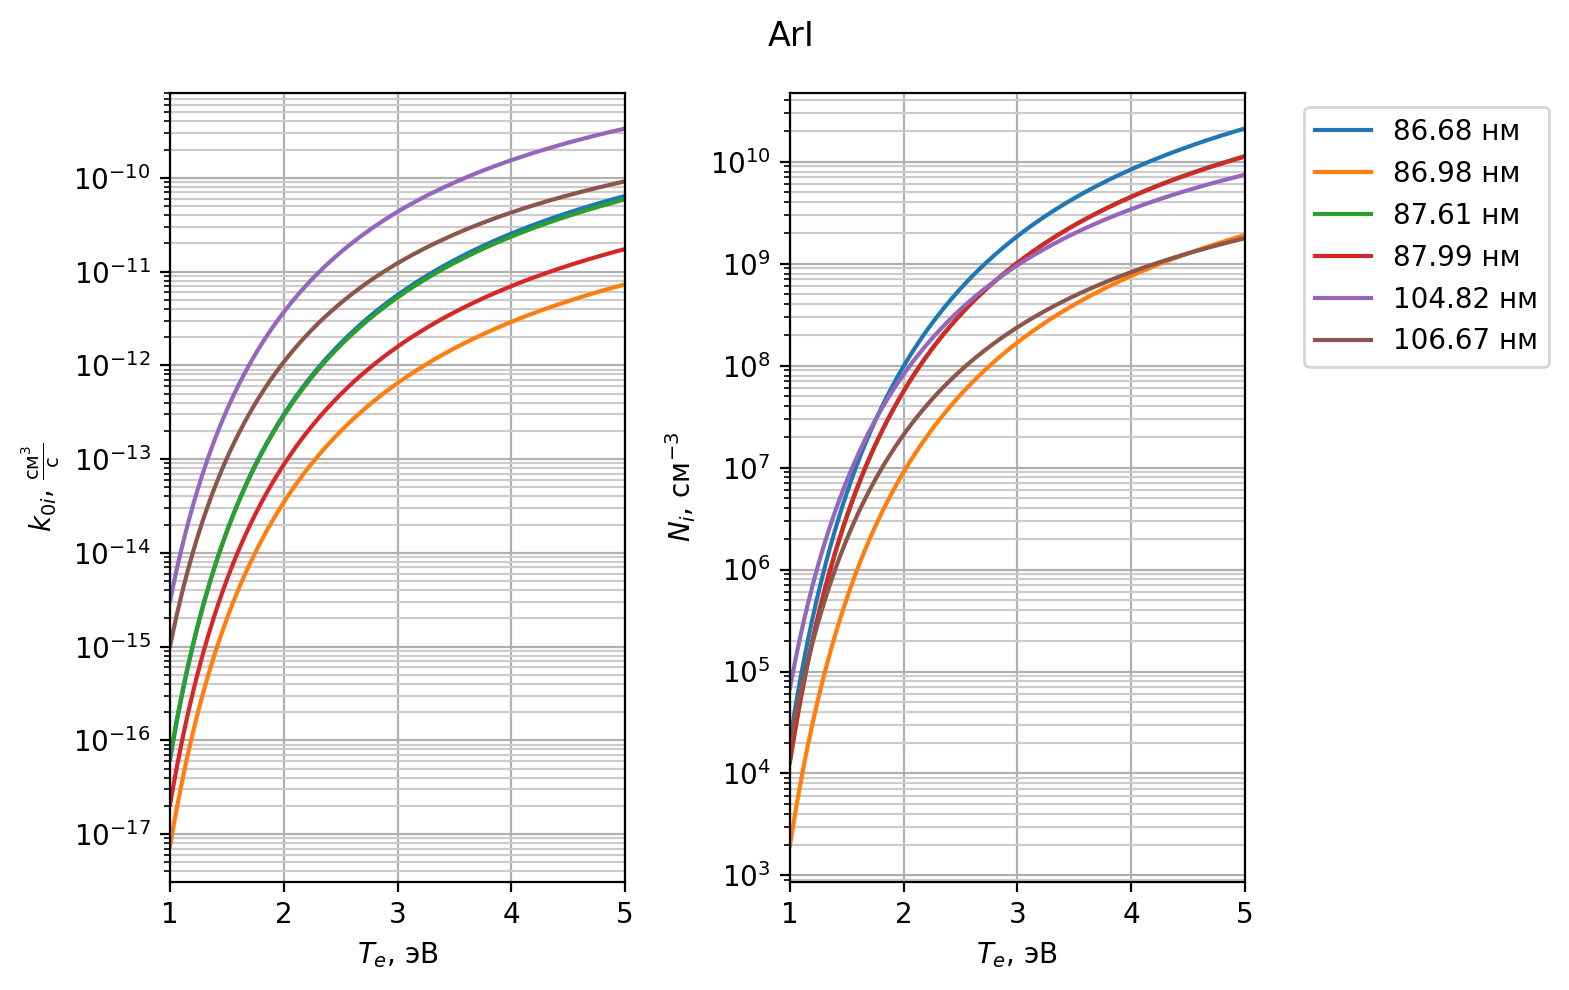

In [9]:
SpectraPlot.title = r"$\mathrm{ArI}$"
SpectraPlot.dplot_T(ArI, N_e, N_n, T)

/tmp/ipykernel_118389/2160064568.py:32: RuntimeWarning: divide by zero encountered in scalar divide
  sum_Aki = 1 / np.sum(self.transitions_from_i(resonants.iloc[i]["conf_k"])["Aki"])


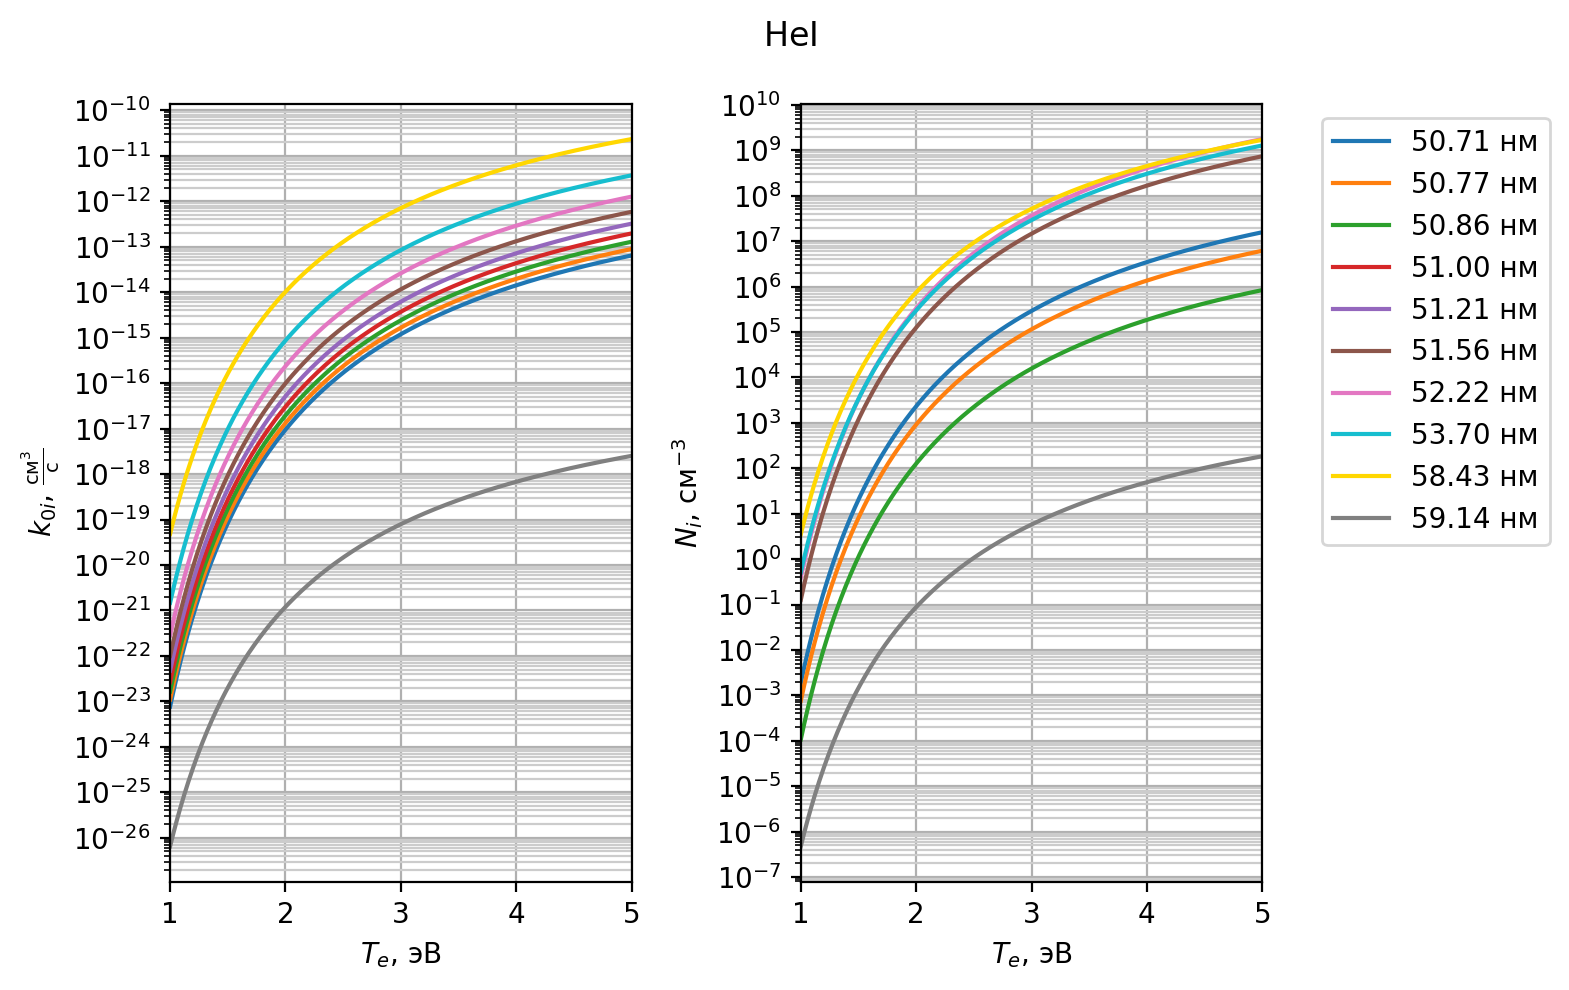

In [10]:
SpectraPlot.title = r"$\mathrm{HeI}$"
SpectraPlot.dplot_T(HeI, N_e, N_n, T)